### Contexto de Negócio

Um dos grandes problemas de negócio de empresas que trabalham com assinaturas é o Churn. Estudar esse problema contribui para entender oportunidades de melhoria do produto/serviço, ocasionando em maior satisfação dos clientes e aumento de faturamento para o negócio.

O objetivo desta análise é identificar os
principais fatores estatísticos e probabilísticos que influenciam o churn em uma empresa de telecomunicações.


### Análise Exploratória

In [ ]:
#Importando as bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
for column in df.columns:
    print(f'{column}: {df[column].unique()}')

customerID: ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
gender: ['Female' 'Male']
SeniorCitizen: [0 1]
Partner: ['Yes' 'No']
Dependents: ['No' 'Yes']
tenure: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26  0
 39]
PhoneService: ['No' 'Yes']
MultipleLines: ['No phone service' 'No' 'Yes']
InternetService: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: ['No' 'Yes' 'No internet service']
OnlineBackup: ['Yes' 'No' 'No internet service']
DeviceProtection: ['No' 'Yes' 'No internet service']
TechSupport: ['No' 'Yes' 'No internet service']
StreamingTV: ['No' 'Yes' 'No internet service']
StreamingMovies: ['No' 'Yes' 'No internet service']
Contract: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: ['Yes' 'No']
PaymentMethod: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)

Podemos ver que não existem colunas com valores ausentes...

In [ ]:
df['TotalCharges'] = df['TotalCharges'].str.replace("'", '')
df['TotalCharges'] = df['TotalCharges'].str.replace(" ", '0').astype(float)

#### Distribuição das Variáveis

In [ ]:
df[['tenure','MonthlyCharges','TotalCharges']].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


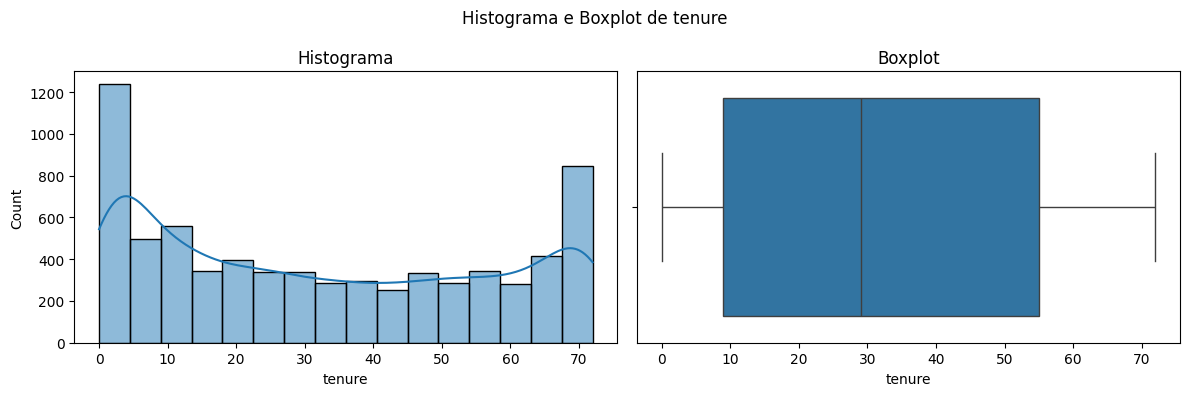

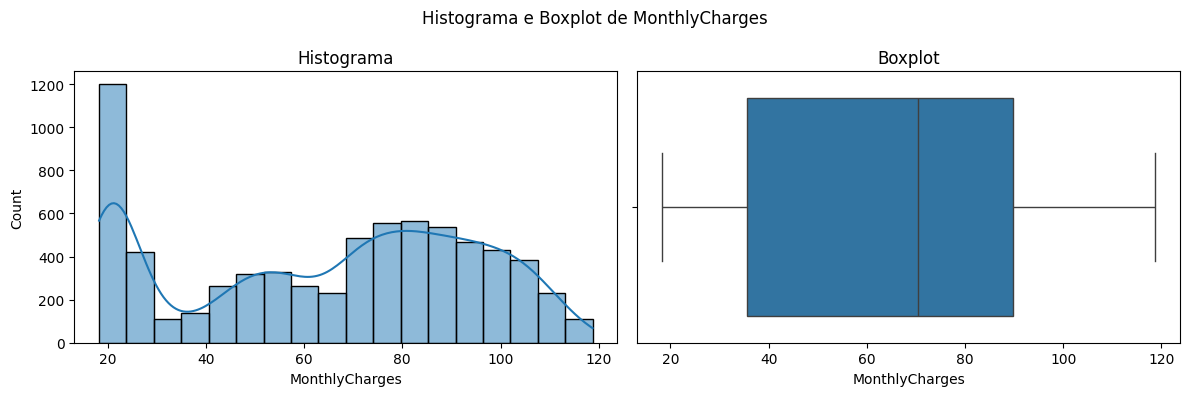

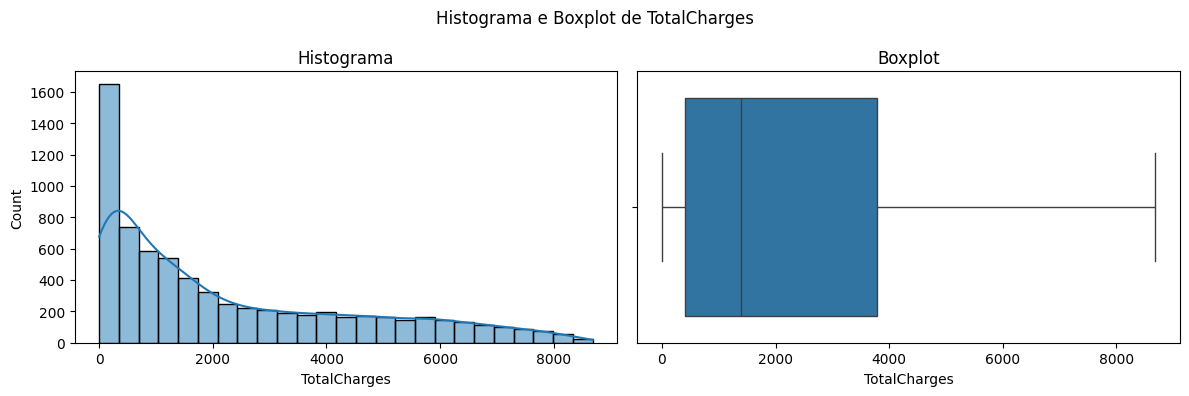

In [ ]:
columns = ['tenure','MonthlyCharges','TotalCharges']
for column in columns:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Histograma e Boxplot de {column}')

    sns.histplot(df[column], kde=True, ax=axs[0])
    axs[0].set_title('Histograma')

    sns.boxplot(x=df[column], ax=axs[1])
    axs[1].set_title('Boxplot')

    plt.tight_layout()
    plt.show()

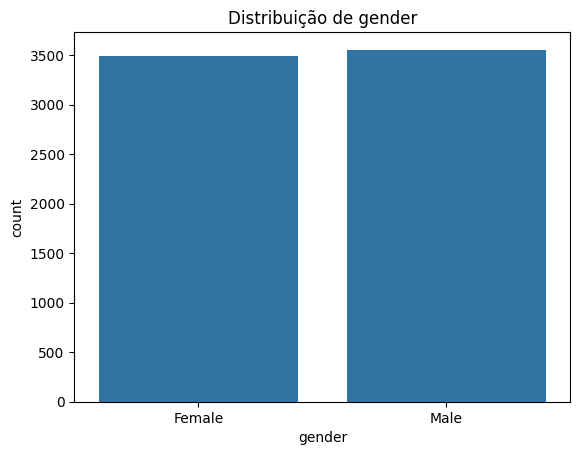

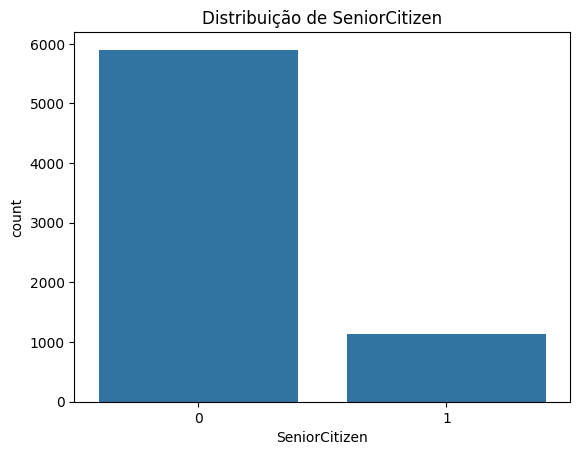

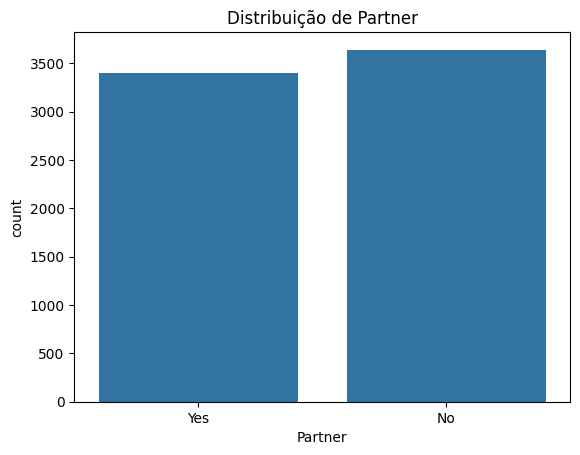

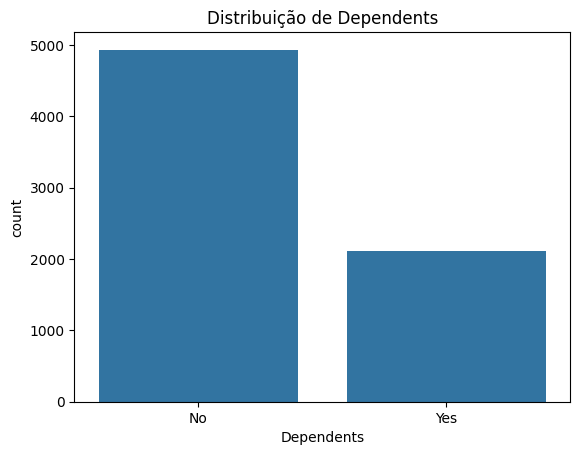

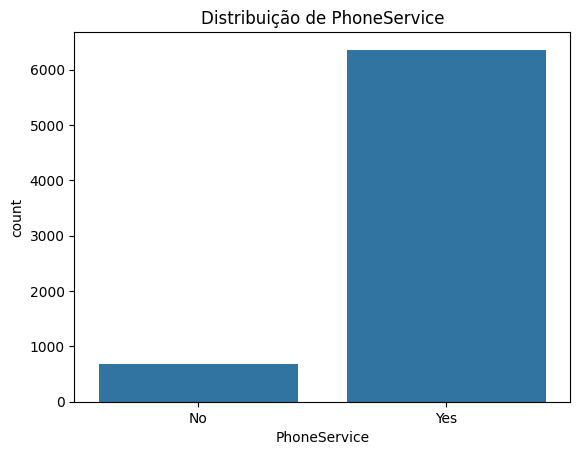

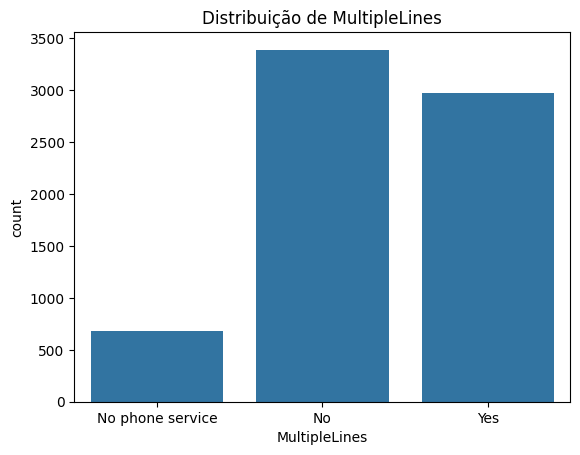

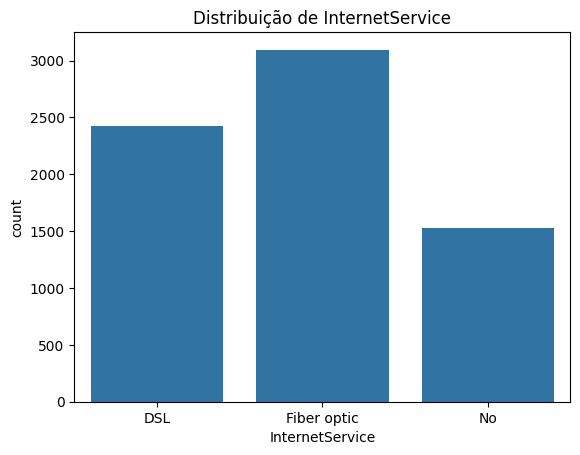

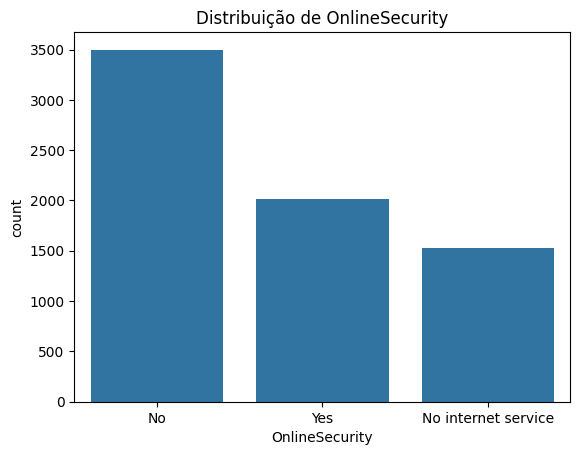

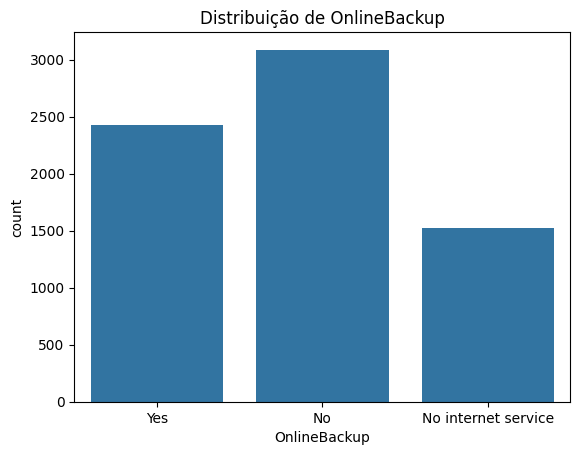

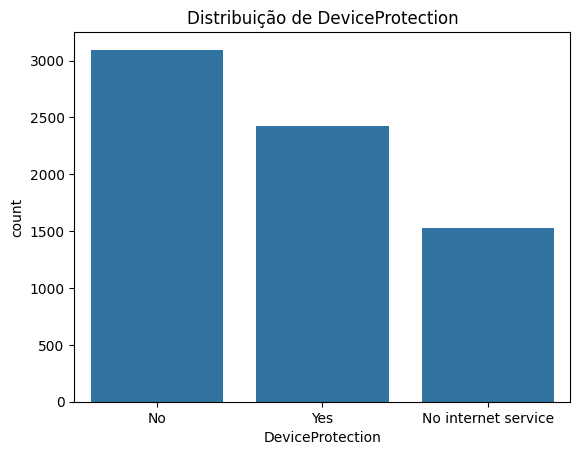

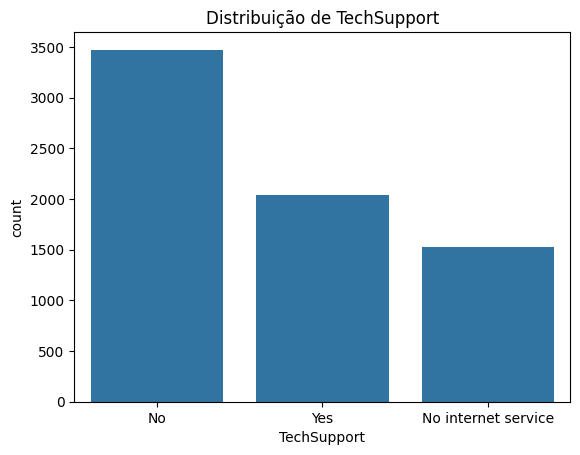

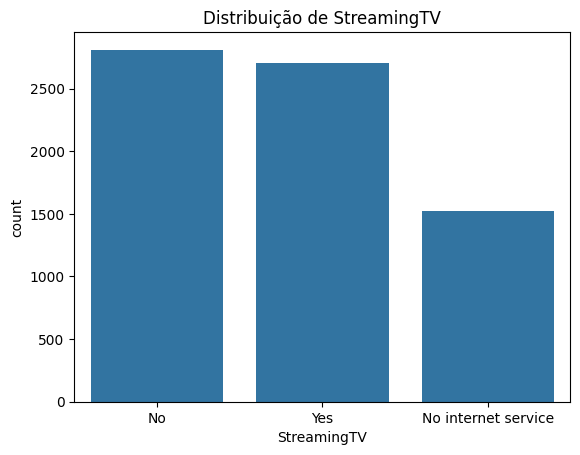

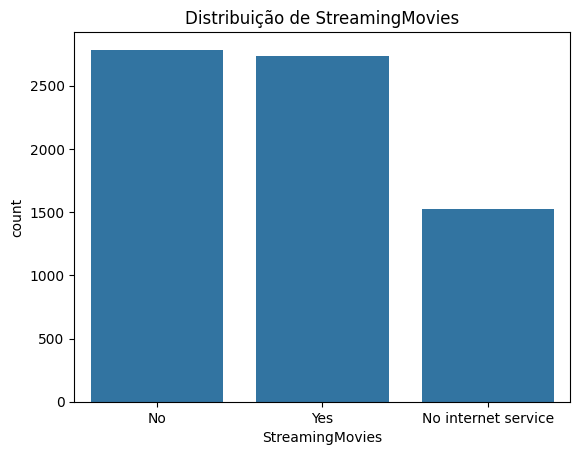

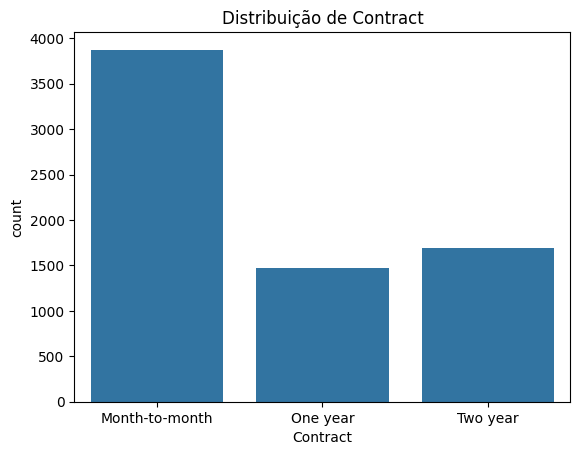

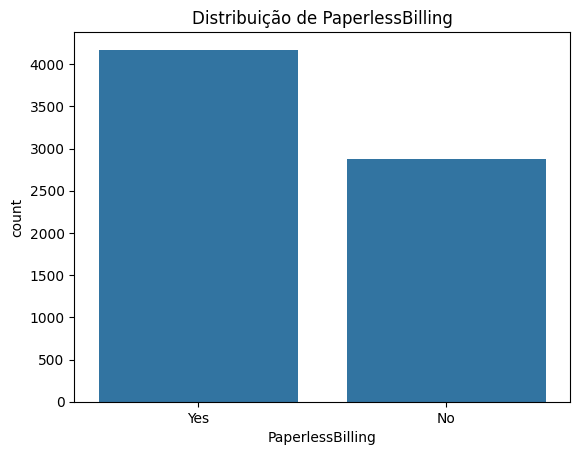

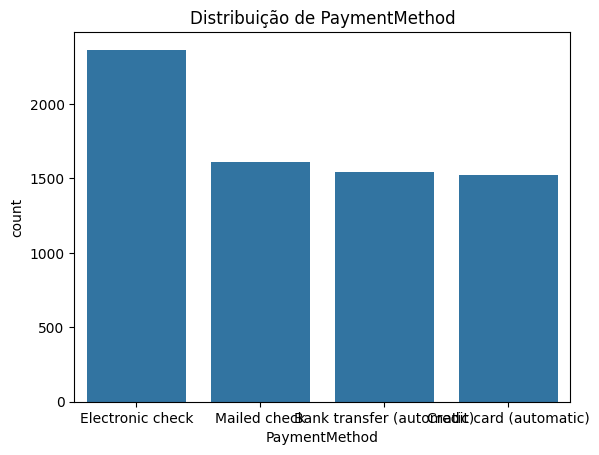

In [ ]:
cat_columns = ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
               'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies','Contract','PaperlessBilling','PaymentMethod']
for column in cat_columns:
  sns.countplot(x=df[column])
  plt.title(f'Distribuição de {column}')
  plt.show()

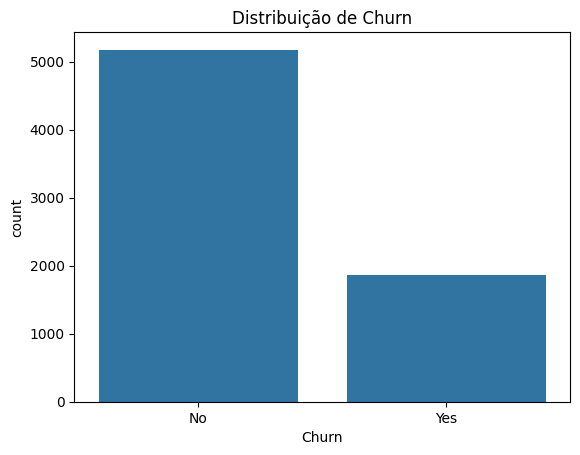

In [ ]:
sns.countplot(x=df['Churn'])
plt.title('Distribuição de Churn')
plt.show()

#### Análise Multivariada

1. Perguntas sobre o Perfil Demográfico do Cliente

Gênero e Idade: A taxa de churn varia significativamente entre homens e mulheres? Clientes mais velhos (SeniorCitizen) têm maior ou menor probabilidade de cancelar o serviço?

Relacionamento e Dependentes: Clientes que possuem um parceiro (Partner) ou dependentes (Dependents) são mais fiéis? A estrutura familiar aumenta a adesão ao serviço?

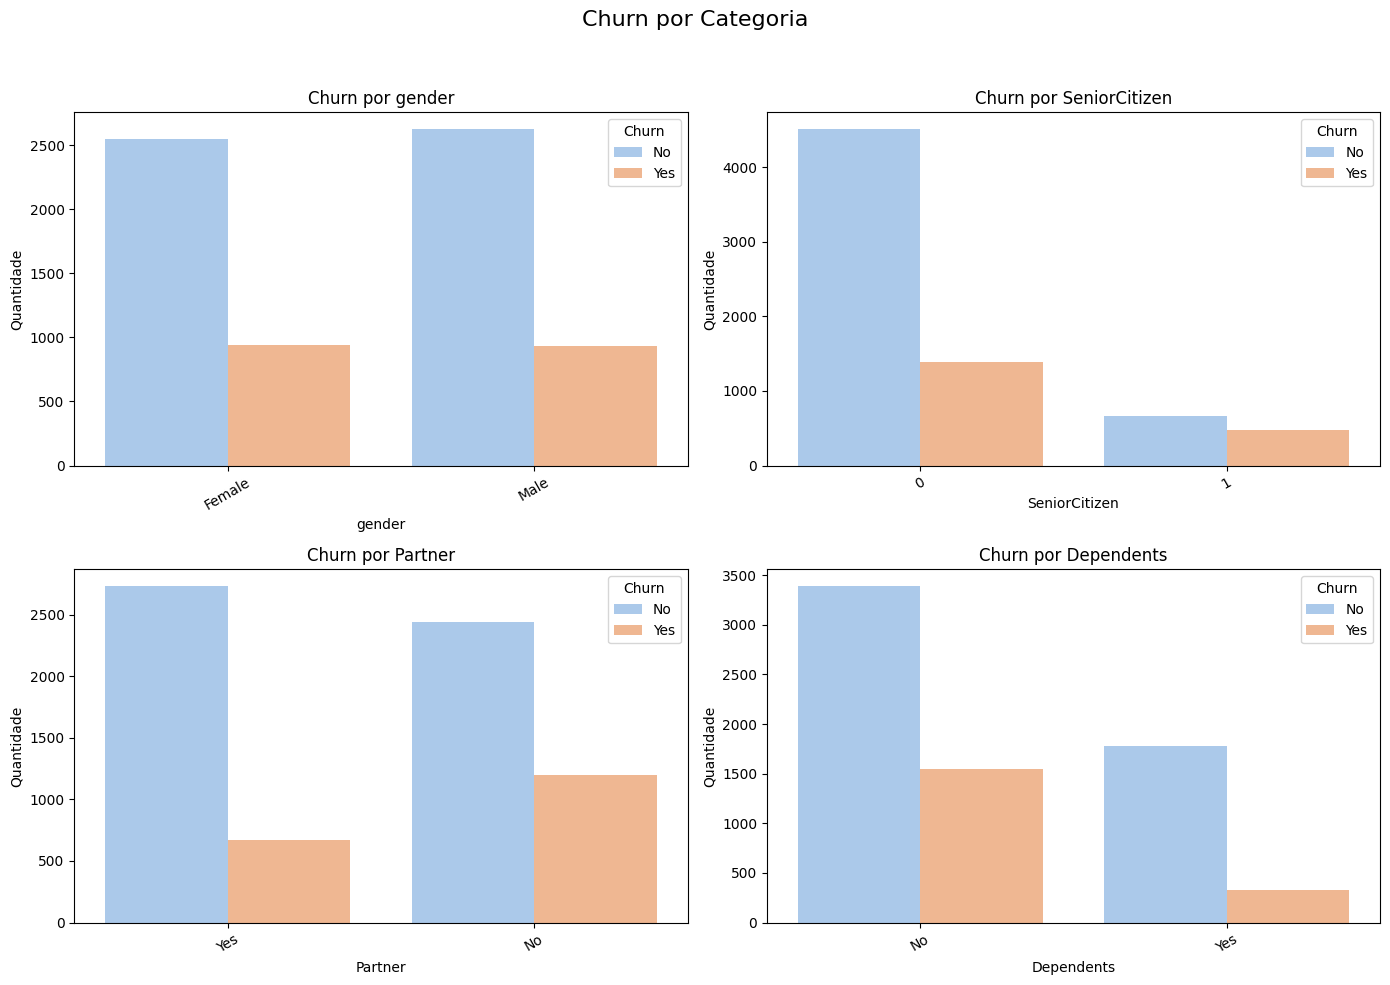

In [ ]:
categorias = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Churn por Categoria', fontsize=16)

axs = axs.flatten()
for i, cat in enumerate(categorias):
    sns.countplot(data=df, x=cat, hue='Churn', ax=axs[i], palette='pastel')
    axs[i].set_title(f'Churn por {cat}')
    axs[i].set_xlabel(cat)
    axs[i].set_ylabel('Quantidade')
    axs[i].tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

2. Perguntas sobre o Contrato e a Relação Financeira
Esta categoria foca em como os aspectos comerciais e a duração do relacionamento impactam a retenção.

Duração do Contrato (Tenure): Como a duração do relacionamento com o cliente se correlaciona com a probabilidade de churn? Existe um "período crítico" nos primeiros meses onde o churn é mais acentuado?

Tipo de Contrato: Qual é o impacto do tipo de contrato (mensal, um ano, dois anos) na taxa de churn? Clientes com contratos mensais, por terem mais flexibilidade, representam a maior parte dos cancelamentos?

Valores Cobrados: Clientes com cobranças mensais mais altas (MonthlyCharges) são mais propensos a cancelar? Ou, inversamente, clientes com cobranças muito baixas cancelam por não perceberem valor?

Método de Pagamento e Fatura: O método de pagamento (PaymentMethod) influencia a taxa de churn? Por exemplo, clientes com débito automático em cartão de crédito cancelam menos do que os que pagam via boleto? A adesão à fatura digital (PaperlessBilling) tem alguma correlação com a satisfação ou churn?

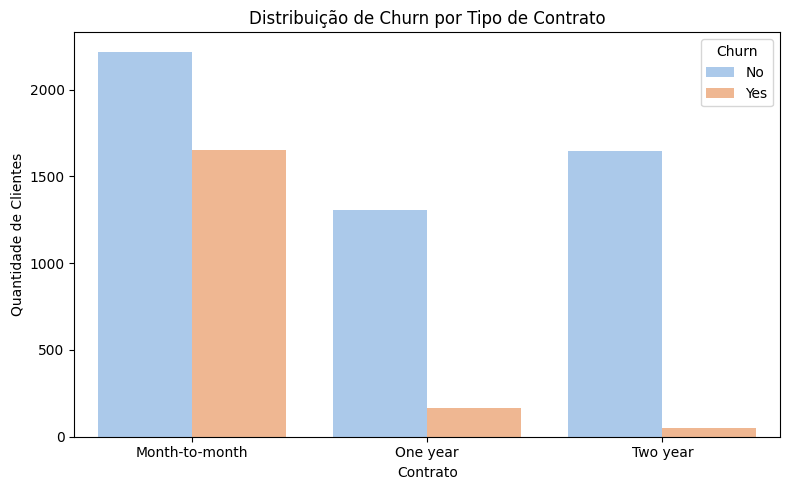

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Contract', hue='Churn', palette='pastel')

plt.title('Distribuição de Churn por Tipo de Contrato')
plt.xlabel('Contrato')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

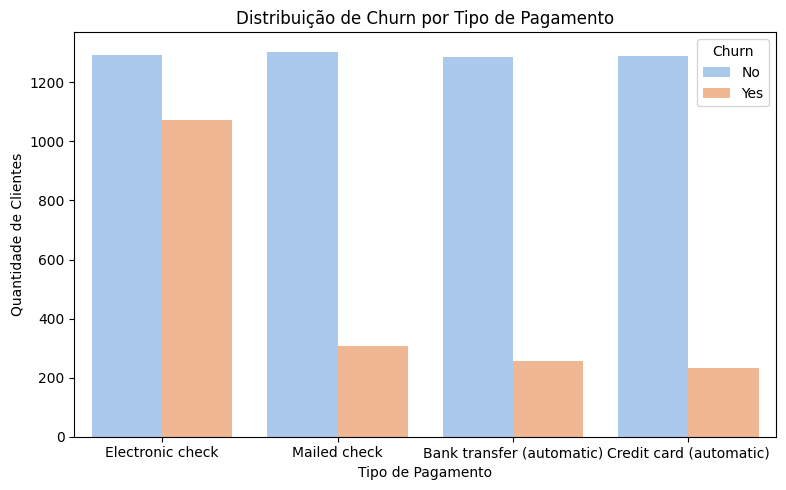

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='PaymentMethod', hue='Churn', palette='pastel')

plt.title('Distribuição de Churn por Tipo de Pagamento')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

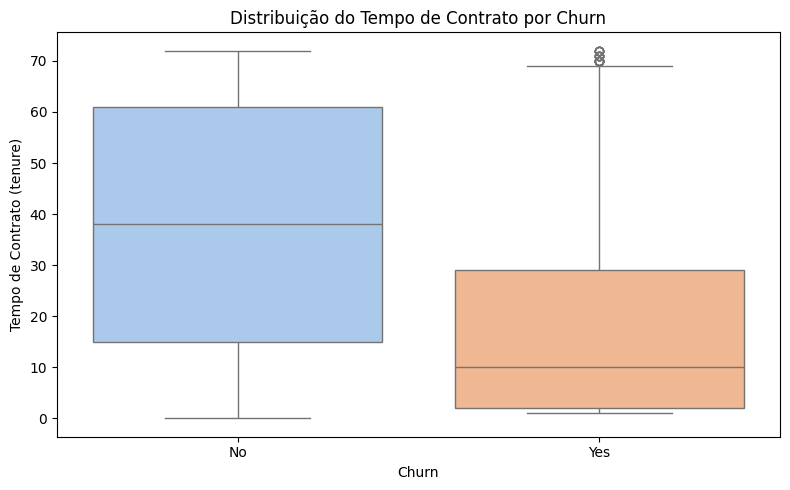

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='tenure', palette='pastel');

plt.title('Distribuição do Tempo de Contrato por Churn')
plt.xlabel('Churn')
plt.ylabel('Tempo de Contrato (tenure)')
plt.tight_layout()
plt.show()

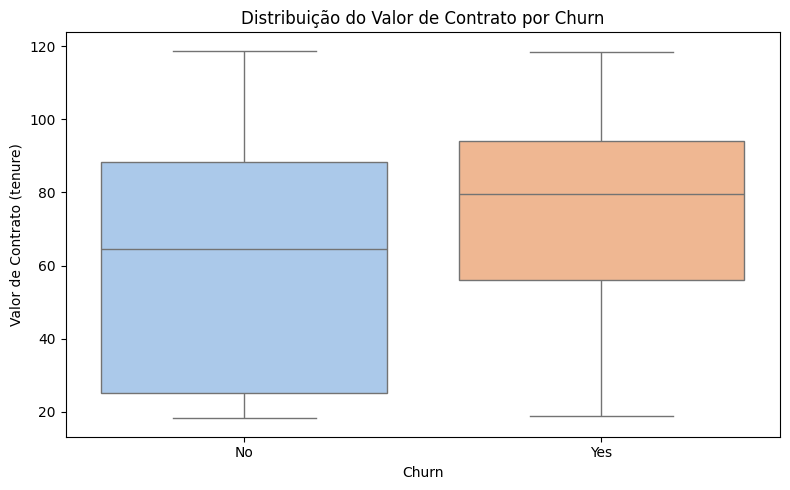

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='pastel')

plt.title('Distribuição do Valor de Contrato por Churn')
plt.xlabel('Churn')
plt.ylabel('Valor de Contrato (tenure)')
plt.tight_layout()
plt.show()

3. Perguntas sobre os Serviços e o Engajamento com o Produto
Aqui, investigamos como o uso e a combinação de diferentes serviços afetam a lealdade do cliente.

Serviço de Internet: Qual tipo de serviço de internet (Fibra Ótica vs. DSL) apresenta a maior taxa de churn? Isso pode indicar problemas de qualidade, preço ou percepção de valor entre eles.

Serviços de Valor Agregado: Clientes que contratam serviços adicionais como OnlineSecurity, OnlineBackup, DeviceProtection e StreamingTV/Movies possuem uma taxa de churn menor? Quantos serviços adicionais são necessários para observar uma queda significativa no churn?

Suporte Técnico: A ausência do serviço de suporte técnico (TechSupport) é um fator determinante para o cancelamento? Essa ausência é mais crítica para algum segmento específico (ex: clientes idosos)?

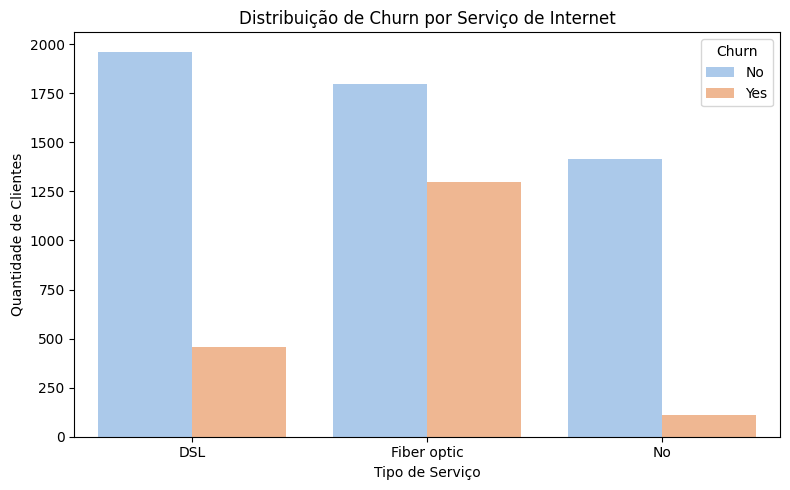

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='InternetService', hue='Churn', palette='pastel')

plt.title('Distribuição de Churn por Serviço de Internet')
plt.xlabel('Tipo de Serviço')
plt.ylabel('Quantidade de Clientes')
plt.legend(title='Churn')
plt.tight_layout()
plt.show()

In [ ]:
servicos_adicionais =df[['customerID','OnlineSecurity','OnlineBackup','DeviceProtection','StreamingTV','StreamingMovies','Churn']]

In [ ]:
servicos_adicionais['DeviceProtection'] = [1 if x == 'Yes' else 0 for x in servicos_adicionais['DeviceProtection']]
servicos_adicionais['OnlineSecurity'] = [1 if x == 'Yes' else 0 for x in servicos_adicionais['OnlineSecurity']]
servicos_adicionais['OnlineBackup'] = [1 if x == 'Yes' else 0 for x in servicos_adicionais['OnlineBackup']]
servicos_adicionais['StreamingTV'] = [1 if x == 'Yes' else 0 for x in servicos_adicionais['StreamingTV']]
servicos_adicionais['StreamingMovies'] = [1 if x == 'Yes' else 0 for x in servicos_adicionais['StreamingMovies']]

In [ ]:
servicos_adicionais['quantidade_servicos'] = servicos_adicionais.iloc[:, 1:-1].sum(axis=1)

In [ ]:
servicos_adicionais.head()

,customerID,OnlineSecurity,OnlineBackup,DeviceProtection,StreamingTV,StreamingMovies,Churn,quantidade_servicos
0,7590-VHVEG,0,1,0,0,0,No,1
1,5575-GNVDE,1,0,1,0,0,No,2
2,3668-QPYBK,1,1,0,0,0,Yes,2
3,7795-CFOCW,1,0,1,0,0,No,2
4,9237-HQITU,0,0,0,0,0,Yes,0


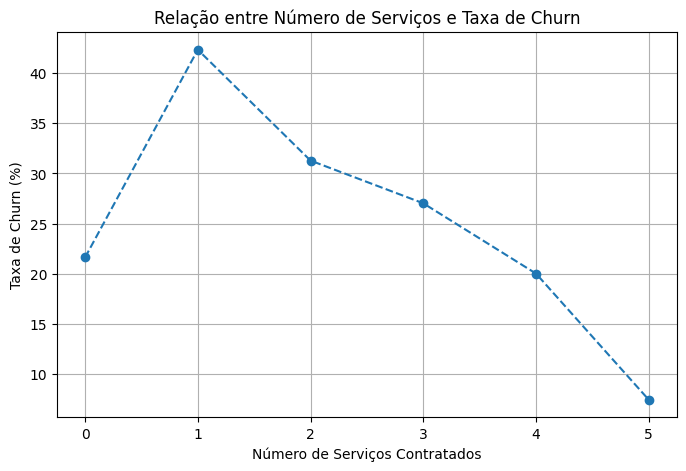

In [ ]:
churn_por_servicos = servicos_adicionais.groupby('quantidade_servicos')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()

plt.figure(figsize=(8, 5))
plt.plot(churn_por_servicos['quantidade_servicos'], churn_por_servicos['Churn'], marker='o', linestyle='--')
plt.xlabel('Número de Serviços Contratados')
plt.ylabel('Taxa de Churn (%)')
plt.title('Relação entre Número de Serviços e Taxa de Churn')
plt.grid(True)
plt.show()

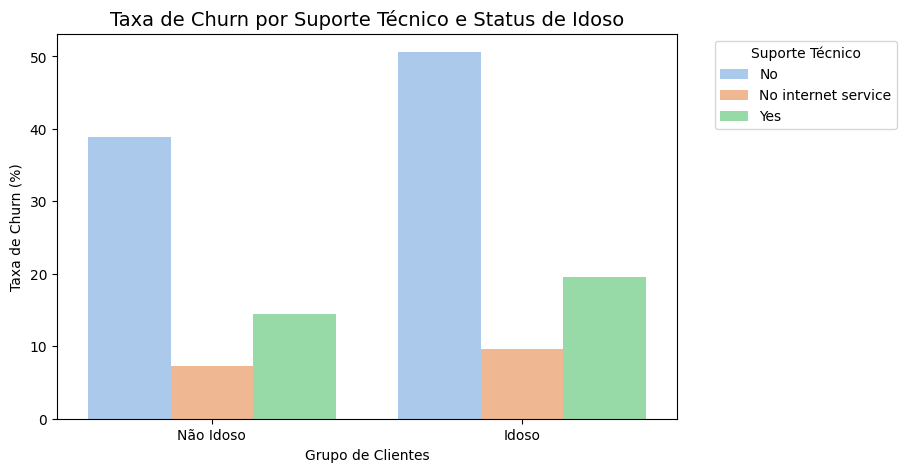

In [ ]:
churn_ = df.groupby(['SeniorCitizen','TechSupport'])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).reset_index()
churn_['SeniorCitizen'] = churn_['SeniorCitizen'].map({0: 'Não Idoso', 1: 'Idoso'})

plt.figure(figsize=(8, 5))
sns.barplot(
    x='SeniorCitizen',
    y='Churn',
    hue='TechSupport',
    data=churn_,
    palette='pastel'
)
plt.title('Taxa de Churn por Suporte Técnico e Status de Idoso', fontsize=14)
plt.xlabel('Grupo de Clientes')
plt.ylabel('Taxa de Churn (%)')
plt.legend(title='Suporte Técnico', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
df_corr = df[['tenure','MonthlyCharges','TotalCharges','Churn']]
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})
df_corr.corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.247900,0.826178,-0.352229
MonthlyCharges,0.247900,1.000000,0.651174,0.193356
TotalCharges,0.826178,0.651174,1.000000,-0.198324
Churn,-0.352229,0.193356,-0.198324,1.000000


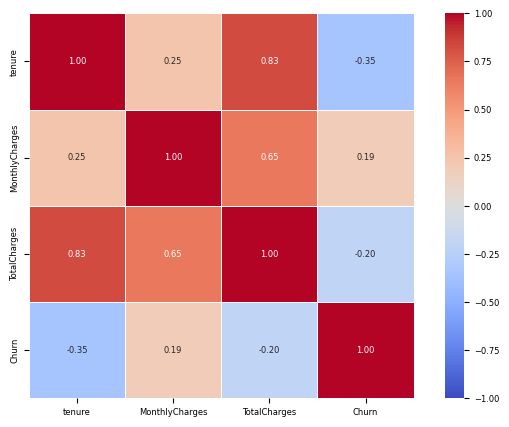

In [ ]:
plt.figure(figsize = (8,5))
plt.rcParams.update({'font.size': 6})
sns.heatmap(df_corr.corr(), cmap = 'coolwarm', vmin = -1, vmax = 1, center = 0, annot=True, fmt=".2f", square=True, linewidths=.5)
plt.show()

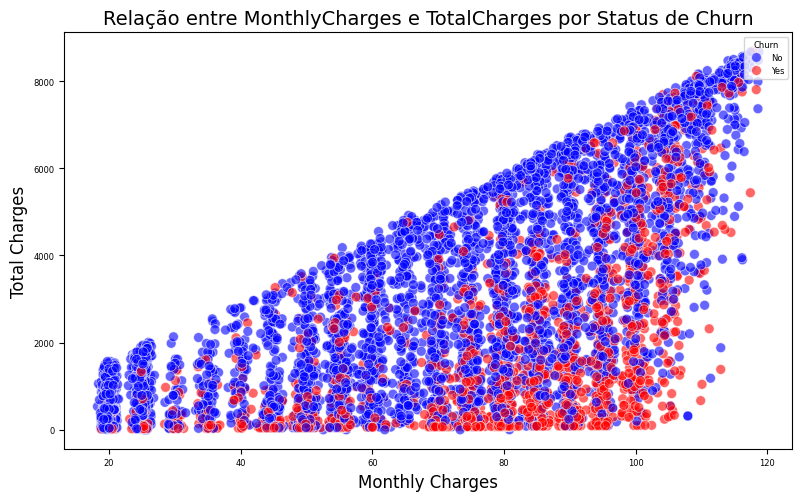

In [ ]:
plt.figure(figsize=(8, 5))
scatter = sns.scatterplot(
    data=df,
    x='MonthlyCharges',
    y='TotalCharges',
    hue='Churn',
    palette={'Yes': 'red', 'No': 'blue'},
    alpha=0.6,
    s=50
)
plt.title('Relação entre MonthlyCharges e TotalCharges por Status de Churn', fontsize=14)
plt.xlabel('Monthly Charges', fontsize=12)
plt.ylabel('Total Charges', fontsize=12)

plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

### Insights e Recomendações

Clientes com contratos mensais apresentam uma taxa de churn maior em comparação com aqueles em contratos de um ou dois anos. Isso indica que a falta de um compromisso de longo prazo é um fator muito relevante para cancelamento do serviço.

Observando o gráfico de correlação, vemos uma correlação negativa forte entre a variável Tenure e Churn, ou seja, clientes mais novos são muito mais propensos a cancelar.

A falta de Suporte Técnico influencia bastante na taxa de Churn, principalmente para clientes idosos.

Clientes que utilizam o serviço de Fibra Ótica têm uma taxa de churn significativamente maior do que os clientes de DSL. Isso, combinado ao fato de que a Fibra geralmente possui uma cobrança mensal mais alta, sugere uma possível sensibilidade ao preço ou uma falha na entrega de valor percebido para justificar o custo maior.

**Recomendações**

Criar uma campanha de migração para clientes do plano mensal, oferecendo um desconto significativo na mensalidade ou a inclusão gratuita de um serviço adicional nos primeiros 6 meses para quem migrar para um contrato anual.O contrato de longo prazo é uma das maiores barreiras contra o churn.

Implementar um programa de "Boas-Vindas" nos primeiros 3 a 6 meses de serviço. Este programa pode incluir tutoriais, contato proativo do suporte técnico e ofertas exclusivas de serviços de streaming (StreamingTV, StreamingMovies) para aumentar o engajamento. O churn é mais acentuado no início da jornada do cliente e aumentar o engajamento e a percepção de valor nesse período crítico é fundamental para estender o vínculo.

O serviço de Fibra Ótica, apesar de premium, é o que mais gera cancelamentos. A empresa pode empacotar alguns serviços como Suporte Técnico e de Segurança com os planos de fibra, talvez absorvendo parte do custo para tornar a oferta mais atrativa e justificar o preço mais alto.



---



# Teste de Hipóteses

Acreditamos que os clientes que
possuem "Serviço de Streaming de Filmes" como parte do pacote gastam, em média, mais do que aqueles que
não possuem. Precisamos de evidências estatísticas para justificar uma nova campanha de marketing que
oferecerá esse serviço como upgrade. Para isso, executaremos um Teste de Hipóteses com clientes que possuem e não possuem o serviço para compararmos as médias de gastos dos dois grupos.


Formulação das Hipóteses:


*   H₀: a média de MonthlyCharges é igual nos dois grupos
*   H₁: a média do grupo B é maior que a do grupo A



In [ ]:
df_teste = df[['MonthlyCharges','StreamingMovies','customerID']]
grupo_a = df_teste[df_teste['StreamingMovies'] == 'No']['MonthlyCharges']
grupo_b = df_teste[df_teste['StreamingMovies'] == 'Yes']['MonthlyCharges']

In [ ]:
import scipy.stats as st

In [ ]:
media_a = np.mean(grupo_a)
desvio_a = np.std(grupo_a)
n_a = len(grupo_a)
media_b = np.mean(grupo_b)
desvio_b = np.std(grupo_b)
n_b = len(grupo_b)

In [ ]:
erro_a = desvio_a / np.sqrt(n_a)
erro_b = desvio_b / np.sqrt(n_b)

In [ ]:
# Intervalo de Confiança do Grupo A
intervalo_confianca = st.t.interval(confidence=.95, df=n_a-1, loc=media_a, scale=erro_a)
print(f"Intervalo de confiança Grupo A: [{intervalo_confianca[0]:.2f}, {intervalo_confianca[1]:.2f}]")

Intervalo de confiança Grupo A: [64.74, 66.13]


In [ ]:
# Intervalo de Confiança do Grupo B
intervalo_confianca_b = st.t.interval(confidence=.95, df=n_b-1, loc=media_b, scale=erro_b)
print(f"Intervalo de confiança Grupo B: [{intervalo_confianca_b[0]:.2f}, {intervalo_confianca_b[1]:.2f}]")

Intervalo de confiança Grupo B: [87.78, 89.17]


In [ ]:
#Teste de Normalidade
normalidade_a = st.shapiro(grupo_a).pvalue > 0.05
normalidade_b = st.shapiro(grupo_b).pvalue > 0.05

print(f"Grupo A é normal? {'Sim' if normalidade_a else 'Não'}")
print(f"Grupo B é normal? {'Sim' if normalidade_b else 'Não'}")

Grupo A é normal? Não
Grupo B é normal? Não


Como as amostras não seguem uma distribuição Normal, iremos utilizar um teste não paramétrico, o teste de Mann-Whitney

In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
u, p_valor = mannwhitneyu(grupo_b, grupo_a, alternative='greater')
print(p_valor)

0.0


In [ ]:
if p_valor <= 0.05:
  print('Rejeitamos a Hipótese Nula')
else:
  print('Não Rejeitamos a Hipótese Nula')

Rejeitamos a Hipótese Nula


## Insights e Recomendações

Observando os intervalos de confiança dos dois grupos, vemos que as médias de gastos são bem diferentes e o grupo B gasta, em média, bem mais que o grupo A. O teste de hipóteses comprova estatisticamente que a média do grupo B é maior que a do grupo A, logo faz sentido seguirmos com a campanha para esse outro grupo de clientes.